# HVM MultiHead Sweep Results (category-conditioned)
Loads all `checkpoints/multihead/hvm_cat/*/best.pt` and visualises performance across sweep axes.

Targets: **SigLIP (1152-d)** and **CLIP-short (768-d)** predicted from HVM neural responses with learned category conditioning (10 categories).

Primary metric: **mean cosine similarity** `(cos_siglip + cos_clip) / 2`. Secondary: 2-AFC per head.
Save-best criterion is `val_mean_cos`; `nce_weight` is swept to balance cosine sim and 2-AFC.

In [1]:
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm

sys.path.insert(0, '..')
from config_const import CHECKPOINT_DIR

SWEEP_AXES = ['nce_weight', 'd_model', 'n_layers', 'shared_dim']
SWEEP_DIR  = CHECKPOINT_DIR / 'multihead' / 'hvm_cat'

def load_one(pt):
    try:
        ckpt = torch.load(pt, weights_only=False, map_location='cpu')
    except Exception:
        return None
    row = {**ckpt['args'], **ckpt['metrics'], 'path': str(pt)}
    if 'test_metrics' in ckpt:
        row.update(ckpt['test_metrics'])
    return row

candidates = sorted(SWEEP_DIR.glob('*/best.pt'))
records = []
with ThreadPoolExecutor(max_workers=8) as pool:
    futures = {pool.submit(load_one, pt): pt for pt in candidates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc='Loading'):
        row = fut.result()
        if row:
            records.append(row)

df = pd.DataFrame(records)
has_test = 'test_cos_siglip' in df.columns

for col in SWEEP_AXES:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col])

SORT_BY = 'val_mean_cos'
show_cols = SWEEP_AXES + ['val_mean_cos', 'val_mean_2afc', 'val_cos_siglip', 'val_cos_clip',
                           'val_2afc_siglip', 'val_2afc_clip']
show_cols = [c for c in show_cols if c in df.columns]

print(f'{len(df)} runs loaded from {SWEEP_DIR}  |  test metrics present: {has_test}')
print(df[show_cols].sort_values(SORT_BY, ascending=False).to_string(index=False))

Loading:   0%|          | 0/24 [00:00<?, ?it/s]

24 runs loaded from /home/yy3658/NeurObjectGen/checkpoints/multihead/hvm_cat  |  test metrics present: True
 nce_weight  d_model  n_layers  shared_dim  val_mean_cos  val_mean_2afc  val_cos_siglip  val_cos_clip  val_2afc_siglip  val_2afc_clip
        0.1       64         2         512      0.908254       0.938202        0.833067      0.983440         0.966292       0.910112
        0.1       64         2         256      0.902509       0.935019        0.833806      0.971213         0.959925       0.910112
        0.1      128         2         512      0.899478       0.938015        0.820140      0.978815         0.965918       0.910112
        0.1      128         2         256      0.899384       0.935768        0.824576      0.974191         0.961423       0.910112
        0.1       64         4         512      0.898907       0.939076        0.831604      0.966210         0.968040       0.910112
        0.1       64         4         256      0.886743       0.932834        0.832825 

## Best run per nce_weight

In [2]:
cols = ['nce_weight', 'd_model', 'n_layers', 'shared_dim',
        'val_mean_cos', 'val_mean_2afc',
        'val_cos_siglip', 'val_cos_clip',
        'val_2afc_siglip', 'val_2afc_clip']
available = [c for c in cols if c in df.columns]
summary = (
    df.sort_values('val_mean_cos', ascending=False)
      .groupby('nce_weight', sort=True)
      .first()
      .reset_index()
)[available]
display(summary)

,nce_weight,d_model,n_layers,shared_dim,val_mean_cos,val_mean_2afc,val_cos_siglip,val_cos_clip,val_2afc_siglip,val_2afc_clip
0,0.1,64,2,512,0.908254,0.938202,0.833067,0.983440,0.966292,0.910112
1,0.5,64,2,512,0.714280,0.943071,0.522070,0.906489,0.976030,0.910112
2,0.8,64,2,512,0.534552,0.943134,0.336235,0.732868,0.976155,0.910112


## Cosine similarity and 2-AFC by sweep axis

/tmp/ipykernel_7693/2137574764.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  nw_cmap  = plt.cm.get_cmap('Set1', len(nw_vals))


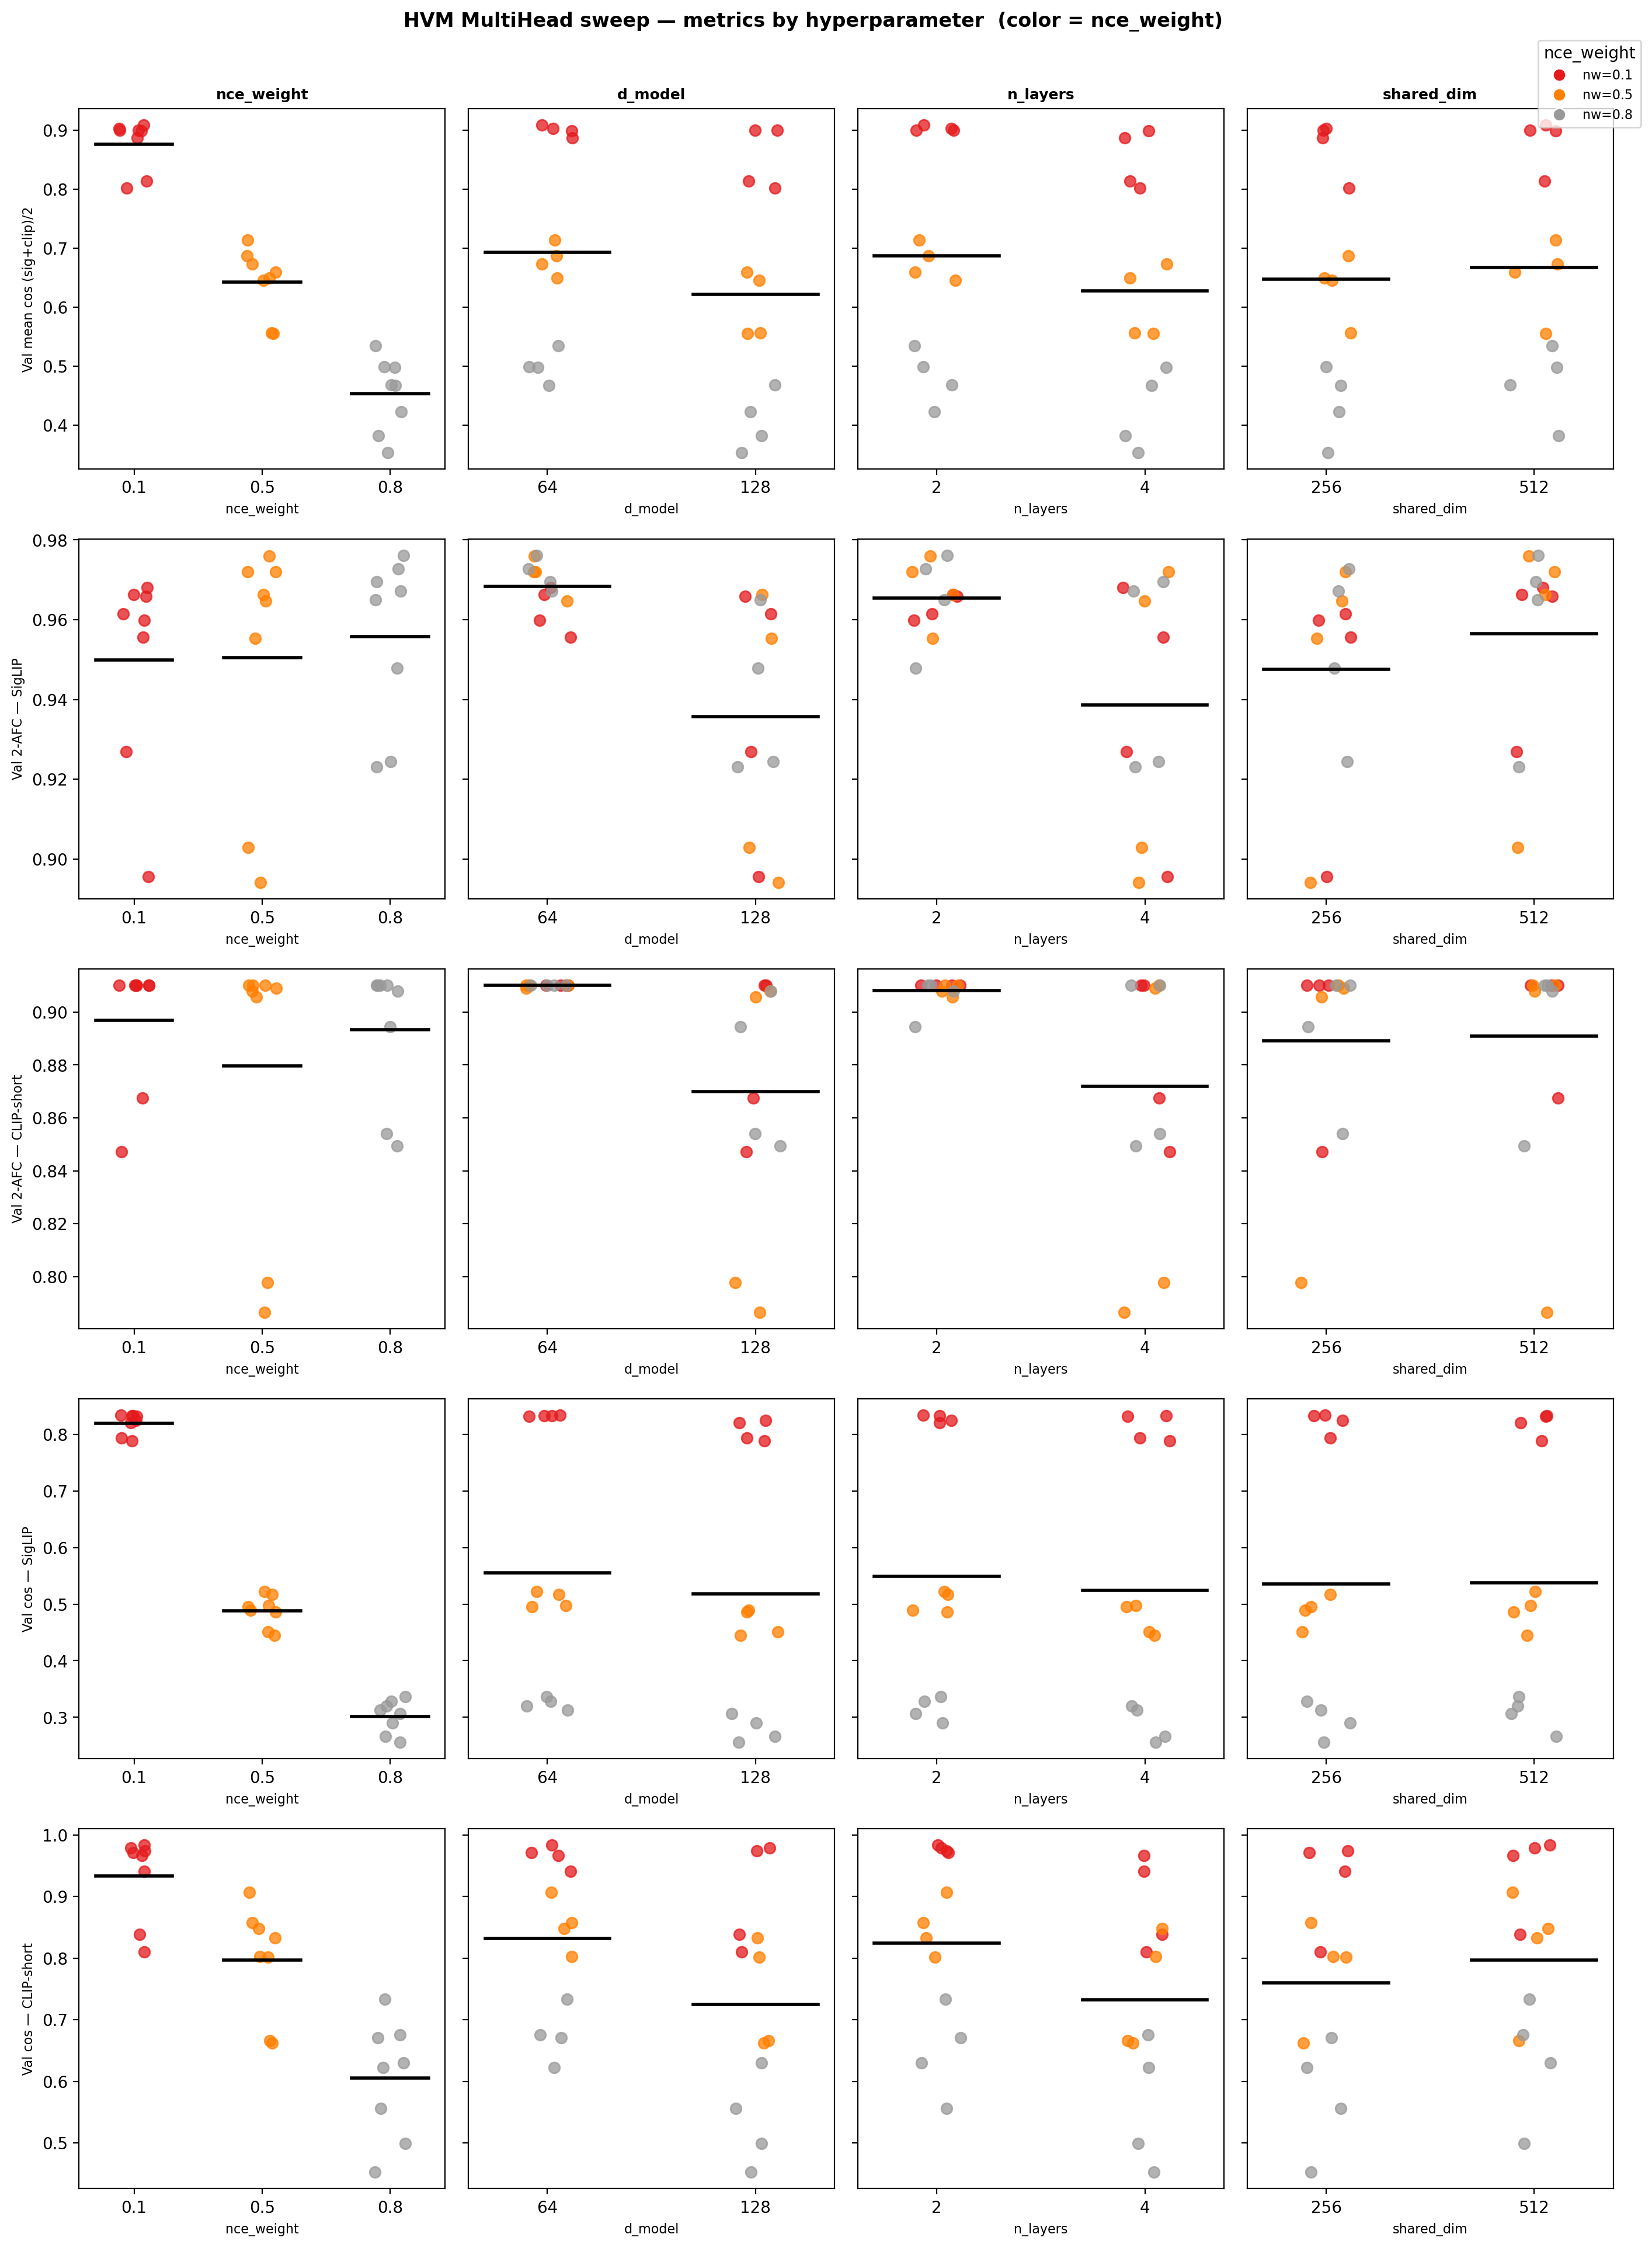

In [3]:
METRICS = [
    ('val_mean_cos',    'Val mean cos (sig+clip)/2'),
    ('val_2afc_siglip', 'Val 2-AFC \u2014 SigLIP'),
    ('val_2afc_clip',   'Val 2-AFC \u2014 CLIP-short'),
    ('val_cos_siglip',  'Val cos \u2014 SigLIP'),
    ('val_cos_clip',    'Val cos \u2014 CLIP-short'),
]

fig, axes = plt.subplots(len(METRICS), len(SWEEP_AXES),
                         figsize=(3.5 * len(SWEEP_AXES), 3.8 * len(METRICS)),
                         sharey='row', squeeze=False)

rng = np.random.default_rng(0)

nw_vals  = sorted(df['nce_weight'].unique())
nw_cmap  = plt.cm.get_cmap('Set1', len(nw_vals))
nw_color = {v: nw_cmap(i) for i, v in enumerate(nw_vals)}

for mi, (metric, ylabel) in enumerate(METRICS):
    if metric not in df.columns:
        continue
    for ai, axis_col in enumerate(SWEEP_AXES):
        ax = axes[mi, ai]
        if axis_col not in df.columns:
            ax.axis('off'); continue
        levels = sorted(df[axis_col].unique())
        for lvl_i, lvl in enumerate(levels):
            sub = df[df[axis_col] == lvl]
            for nw, grp in sub.groupby('nce_weight'):
                vals = grp[metric].dropna().values
                if not len(vals): continue
                jitter = rng.uniform(-0.12, 0.12, len(vals))
                ax.scatter(np.full(len(vals), lvl_i) + jitter, vals,
                           color=nw_color[nw], alpha=0.75, s=45,
                           label=f'nw={nw}' if ai == 0 and lvl_i == 0 else '_')
            all_vals = sub[metric].dropna().values
            if len(all_vals):
                ax.plot([lvl_i - 0.3, lvl_i + 0.3],
                        [all_vals.mean(), all_vals.mean()], 'k-', lw=2)
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels([str(l) for l in levels])
        ax.set_xlabel(axis_col, fontsize=8)
        if ai == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        if mi == 0:
            ax.set_title(axis_col, fontsize=9, fontweight='bold')

handles = [plt.Line2D([0],[0],marker='o',color='w',
           markerfacecolor=nw_color[v],markersize=8,label=f'nw={v}') for v in nw_vals]
fig.legend(handles=handles, title='nce_weight', loc='upper right',
           bbox_to_anchor=(1.01, 1), fontsize=8)
fig.suptitle('HVM MultiHead sweep \u2014 metrics by hyperparameter  (color = nce_weight)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Effect of nce_weight \u2014 key ablation

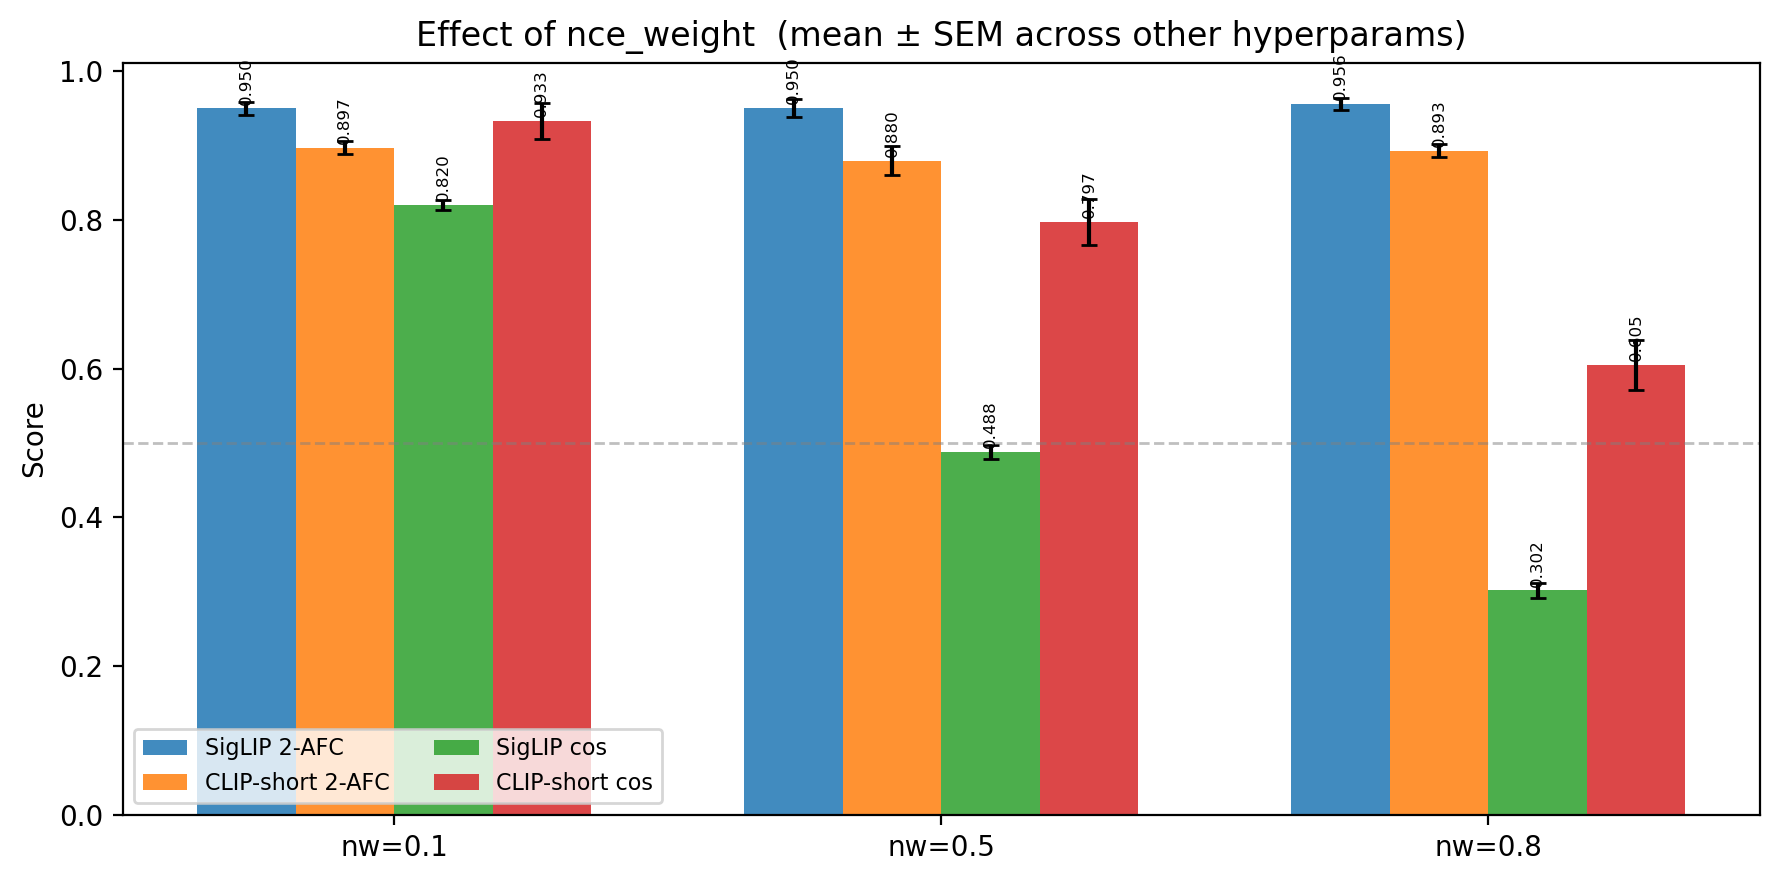

In [4]:
metrics_ab = [
    ('val_2afc_siglip', 'SigLIP 2-AFC'),
    ('val_2afc_clip',   'CLIP-short 2-AFC'),
    ('val_cos_siglip',  'SigLIP cos'),
    ('val_cos_clip',    'CLIP-short cos'),
]
metrics_ab = [(m, l) for m, l in metrics_ab if m in df.columns]
nw_labels = sorted(df['nce_weight'].unique())
x = np.arange(len(nw_labels))
width = 0.18

fig, ax = plt.subplots(figsize=(9, 4.5))
offsets = np.linspace(-(len(metrics_ab)-1)/2, (len(metrics_ab)-1)/2, len(metrics_ab)) * width

for off, (metric, label) in zip(offsets, metrics_ab):
    means = [df[df['nce_weight'] == w][metric].mean() for w in nw_labels]
    sems  = [df[df['nce_weight'] == w][metric].sem()  for w in nw_labels]
    bars  = ax.bar(x + off, means, width, yerr=sems, capsize=3, label=label, alpha=0.85)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([f'nw={v}' for v in nw_labels])
ax.set_ylabel('Score')
ax.set_title('Effect of nce_weight  (mean \u00b1 SEM across other hyperparams)')
ax.legend(fontsize=8, ncol=2)
ax.axhline(0.5, color='grey', lw=1, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Val vs test generalisation

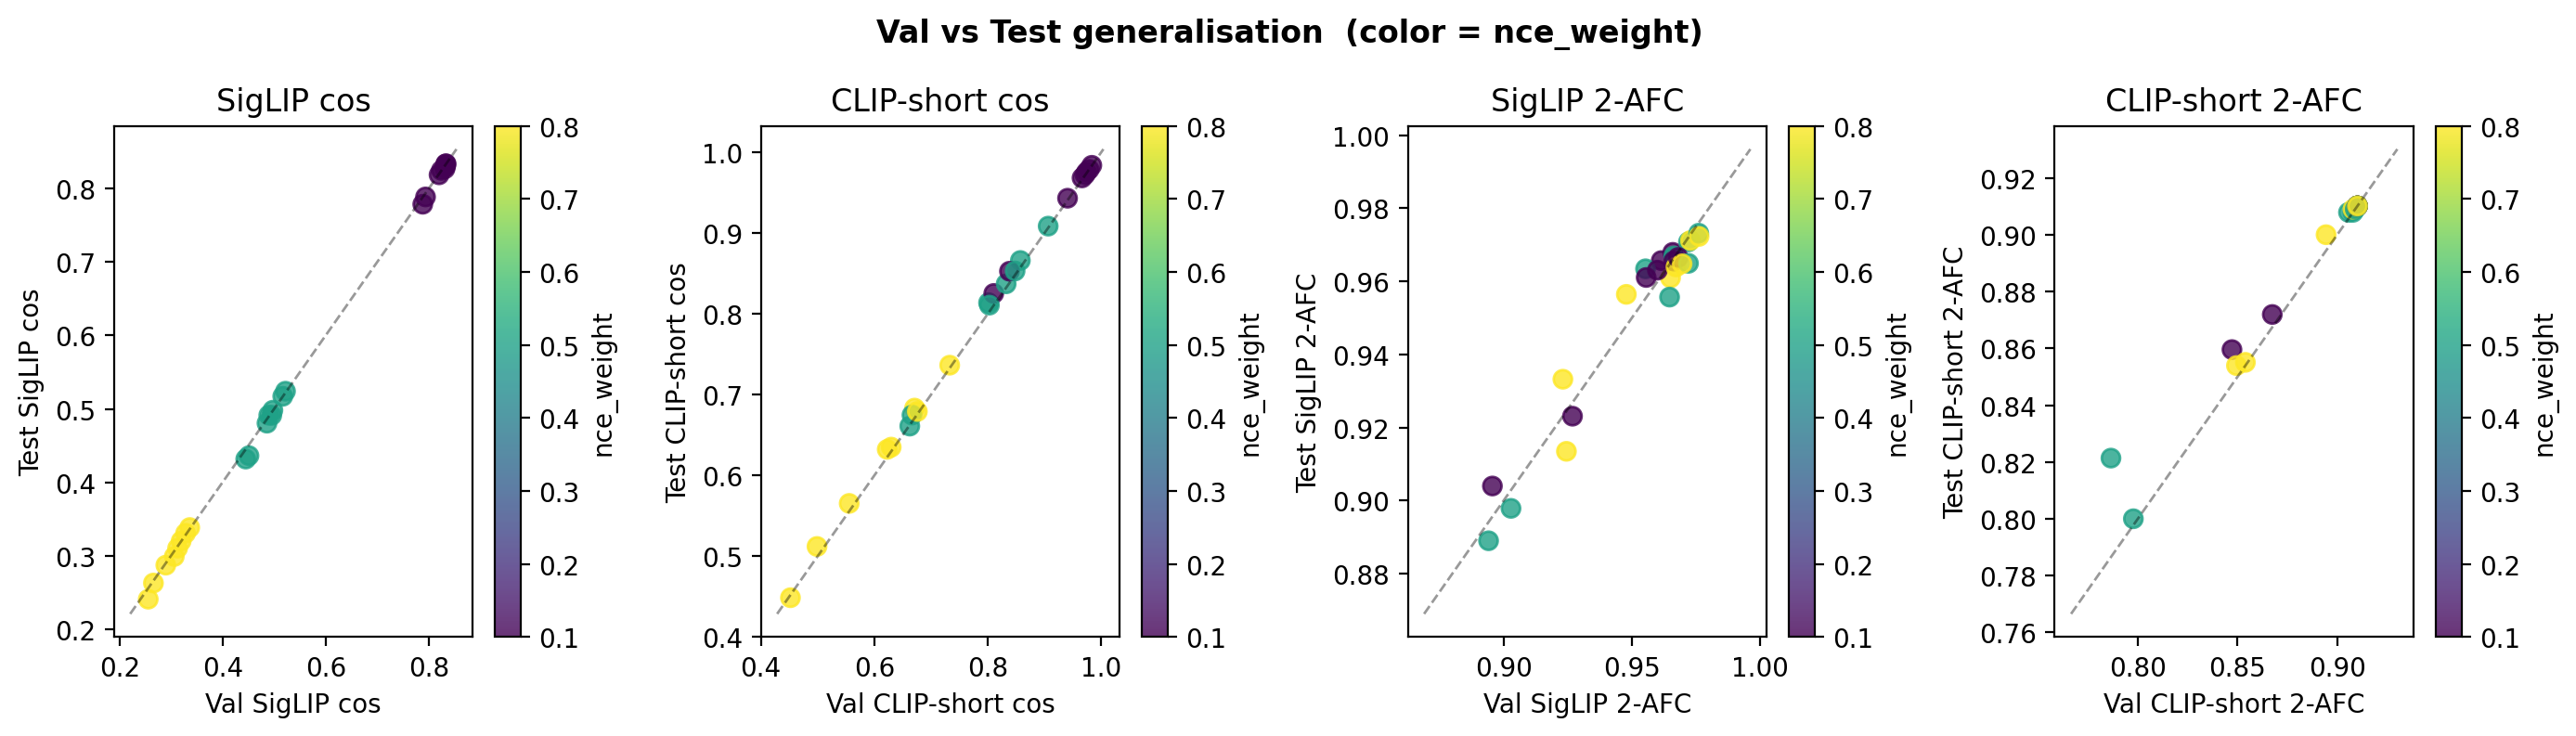

In [5]:
if has_test:
    pairs = [("val_cos_siglip","test_cos_siglip","SigLIP cos"),
             ("val_cos_clip",  "test_cos_clip",  "CLIP-short cos"),
             ("val_2afc_siglip","test_2afc_siglip","SigLIP 2-AFC"),
             ("val_2afc_clip",  "test_2afc_clip",  "CLIP-short 2-AFC")]
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    for ax, (vcol, tcol, title) in zip(axes, pairs):
        sub = df.dropna(subset=[vcol, tcol])
        sc = ax.scatter(sub[vcol], sub[tcol],
                        c=sub['nce_weight'], cmap='viridis',
                        vmin=sub['nce_weight'].min(),
                        vmax=sub['nce_weight'].max(),
                        s=50, alpha=0.8)
        lim = [min(sub[vcol].min(), sub[tcol].min()) - 0.02,
               max(sub[vcol].max(), sub[tcol].max()) + 0.02]
        ax.plot(lim, lim, 'k--', lw=1, alpha=0.4)
        ax.set_xlabel(f'Val {title}')
        ax.set_ylabel(f'Test {title}')
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label='nce_weight')
    fig.suptitle('Val vs Test generalisation  (color = nce_weight)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Test metrics not yet available \u2014 rerun once all jobs complete.')

## Top-10 runs by val mean cosine similarity

In [6]:
top_cols = [c for c in
    ['nce_weight', 'd_model', 'n_layers', 'shared_dim',
     'epoch', 'val_mean_cos', 'val_mean_2afc',
     'val_cos_siglip', 'val_cos_clip',
     'val_2afc_siglip', 'val_2afc_clip',
     'test_cos_siglip', 'test_cos_clip',
     'test_2afc_siglip', 'test_2afc_clip', 'path']
    if c in df.columns]
display(df.sort_values('val_mean_cos', ascending=False)[top_cols].head(10).reset_index(drop=True))

,nce_weight,d_model,n_layers,shared_dim,epoch,val_mean_cos,val_mean_2afc,val_cos_siglip,val_cos_clip,val_2afc_siglip,val_2afc_clip,test_cos_siglip,test_cos_clip,test_2afc_siglip,test_2afc_clip,path
0,0.1,64,2,512,135,0.908254,0.938202,0.833067,0.983440,0.966292,0.910112,0.833768,0.983874,0.965543,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
1,0.1,64,2,256,174,0.902509,0.935019,0.833806,0.971213,0.959925,0.910112,0.833874,0.972064,0.963046,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
2,0.1,128,2,512,134,0.899478,0.938015,0.820140,0.978815,0.965918,0.910112,0.818893,0.978795,0.967915,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
3,0.1,128,2,256,150,0.899384,0.935768,0.824576,0.974191,0.961423,0.910112,0.825015,0.975459,0.965668,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
4,0.1,64,4,512,156,0.898907,0.939076,0.831604,0.966210,0.968040,0.910112,0.827115,0.968290,0.966542,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
5,0.1,64,4,256,178,0.886743,0.932834,0.832825,0.940661,0.955556,0.910112,0.830756,0.943134,0.961049,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
6,0.1,128,4,512,178,0.813383,0.897129,0.788511,0.838254,0.926841,0.867416,0.778838,0.852775,0.923096,0.871910,/home/yy3658/NeurObjectGen/checkpoints/multihe...
7,0.1,128,4,256,181,0.802202,0.871411,0.793850,0.810555,0.895630,0.847191,0.788763,0.825267,0.903995,0.859551,/home/yy3658/NeurObjectGen/checkpoints/multihe...
8,0.5,64,2,512,175,0.714280,0.943071,0.522070,0.906489,0.976030,0.910112,0.524053,0.908588,0.973159,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...
9,0.5,64,2,256,195,0.687123,0.941074,0.516798,0.857447,0.972035,0.910112,0.517148,0.866063,0.970787,0.910112,/home/yy3658/NeurObjectGen/checkpoints/multihe...


## Save best HVM multihead config

In [7]:
import json
from config_const import CACHE_DIR

best_row = df.sort_values('val_mean_cos', ascending=False).iloc[0]
config = {
    'model': 'multihead',
    'dataset': 'hvm',
    'use_category': bool(best_row.get('use_category', True)),
    'val_mean_cos':    float(best_row['val_mean_cos']),
    'val_mean_2afc':   float(best_row['val_mean_2afc']),
    'checkpoint': best_row['path'],
    'd_model':    int(best_row['d_model']),
    'n_heads':    int(best_row['n_heads']),
    'n_layers':   int(best_row['n_layers']),
    'shared_dim': int(best_row['shared_dim']),
    'dropout':    float(best_row['dropout']),
    'lr':         float(best_row['lr']),
    'weight_decay':       float(best_row['weight_decay']),
    'nce_weight':         float(best_row['nce_weight']),
    'loss_weight_siglip': float(best_row['loss_weight_siglip']),
    'loss_weight_clip':   float(best_row['loss_weight_clip']),
}

out_path = CACHE_DIR / 'best_hvm_multihead_config.json'
with open(out_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved to {out_path}')
print(f"  val_mean_cos={config['val_mean_cos']:.4f}")
print(f"  val_mean_2afc={config['val_mean_2afc']:.4f}")
print(f"  {config['checkpoint']}")

Saved to /home/yy3658/NeurObjectGen/cache/best_hvm_multihead_config.json
  val_mean_cos=0.9083
  val_mean_2afc=0.9382
  /home/yy3658/NeurObjectGen/checkpoints/multihead/hvm_cat/d64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs128_ws1.0_wc1.0_uw0.1_nw0.1_nt0.07/best.pt
